# Demand Forecasting — EDA

Exploring `sales_data.csv` (Kaggle: retail store inventory and demand forecasting) before feature engineering. Goal: confirm data quality, understand demand distribution, and check that `Promotion`/`Discount`/`Seasonality` actually move demand (these are the signals the resume bullet claims the pipeline uses).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from forecasting.data import load_sales_data

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

df = load_sales_data()
df.shape

(76000, 16)

In [2]:
df.info()
df.describe(include="all").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                76000 non-null  datetime64[ns]
 1   store_id            76000 non-null  category      
 2   product_id          76000 non-null  category      
 3   category            76000 non-null  category      
 4   region              76000 non-null  category      
 5   inventory_level     76000 non-null  int64         
 6   units_sold          76000 non-null  int64         
 7   units_ordered       76000 non-null  int64         
 8   price               76000 non-null  float64       
 9   discount            76000 non-null  int64         
 10  weather_condition   76000 non-null  category      
 11  promotion           76000 non-null  int8          
 12  competitor_pricing  76000 non-null  float64       
 13  seasonality         76000 non-null  category  

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
date,76000,NaN,NaN,NaN,2023-01-15 12:00:00,2022-01-01 00:00:00,2022-07-09 18:00:00,2023-01-15 12:00:00,2023-07-24 06:00:00,2024-01-30 00:00:00,NaN
store_id,76000,5,S001,15200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_id,76000,20,P0001,3800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,76000,5,Groceries,30400,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,76000,4,North,30400,NaN,NaN,NaN,NaN,NaN,NaN,NaN
inventory_level,76000.0,NaN,NaN,NaN,301.062842,0.0,136.0,227.0,408.0,2267.0,226.510161
units_sold,76000.0,NaN,NaN,NaN,88.827316,0.0,58.0,84.0,114.0,426.0,43.994525
units_ordered,76000.0,NaN,NaN,NaN,89.090645,0.0,0.0,0.0,121.0,1616.0,162.404627
price,76000.0,NaN,NaN,NaN,67.726028,4.74,31.9975,64.5,95.83,228.03,39.377899
discount,76000.0,NaN,NaN,NaN,9.087039,0.0,5.0,10.0,10.0,25.0,7.475781


## Coverage and continuity per SKU-store pair

Confirms the panel is a clean daily series with no gaps, which is what makes lag/rolling features valid without imputation.

In [3]:
group_sizes = df.groupby(["product_id", "store_id"], observed=True).size()
print("rows per sku-store pair:", group_sizes.describe())
print("date range:", df["date"].min(), "to", df["date"].max())
print("missing values:\n", df.isna().sum()[df.isna().sum() > 0])

rows per sku-store pair: count    100.0
mean     760.0
std        0.0
min      760.0
25%      760.0
50%      760.0
75%      760.0
max      760.0
dtype: float64
date range: 2022-01-01 00:00:00 to 2024-01-30 00:00:00
missing values:
 Series([], dtype: int64)


## Demand distribution

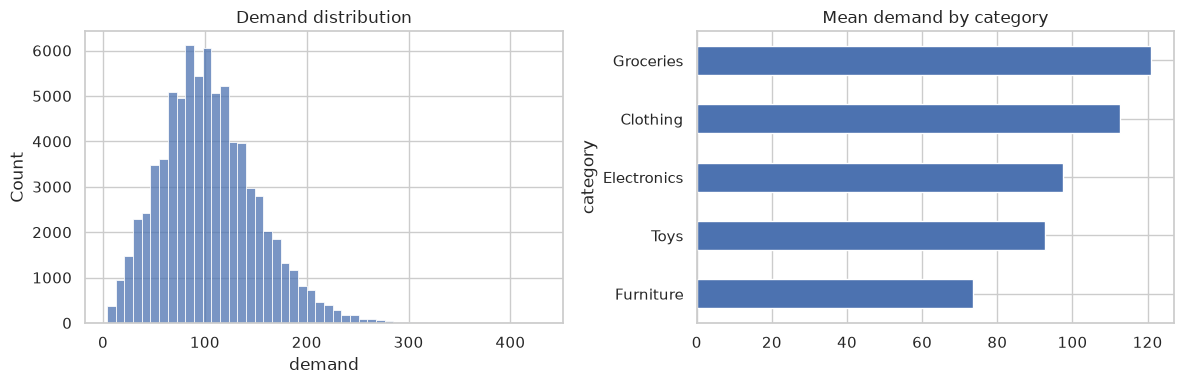

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["demand"], bins=50, ax=axes[0])
axes[0].set_title("Demand distribution")

df.groupby("category", observed=True)["demand"].mean().sort_values().plot.barh(ax=axes[1])
axes[1].set_title("Mean demand by category")
plt.tight_layout()

## Seasonality and time trend

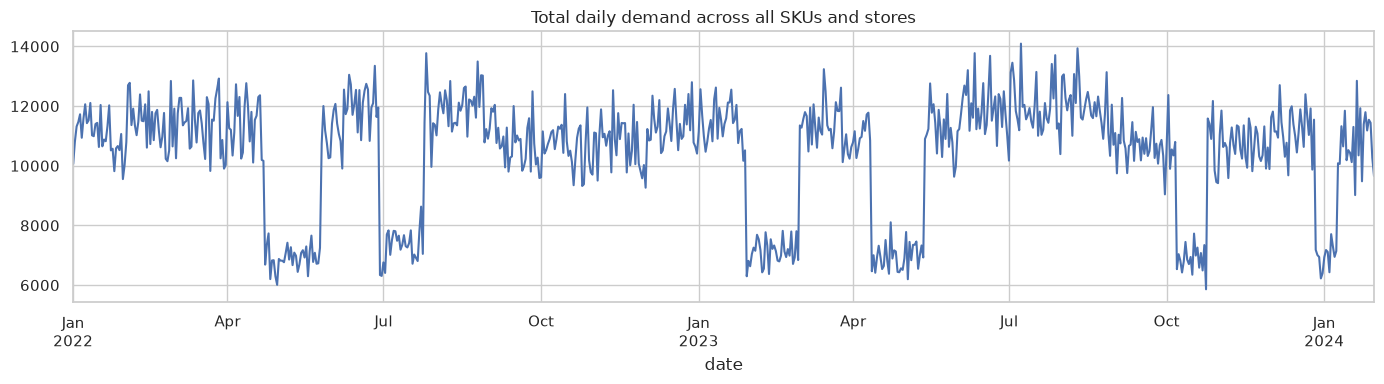

In [5]:
daily = df.groupby("date")["demand"].sum()
fig, ax = plt.subplots(figsize=(14, 4))
daily.plot(ax=ax)
ax.set_title("Total daily demand across all SKUs and stores")
plt.tight_layout()

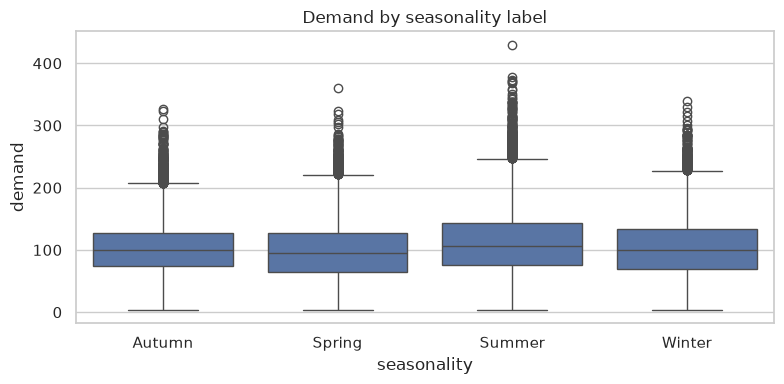

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df, x="seasonality", y="demand", ax=ax)
ax.set_title("Demand by seasonality label")
plt.tight_layout()

## Promotion and discount effect on demand

promotion
0     95.026843
1    123.269400
Name: demand, dtype: float64


          discount    demand
discount  1.000000  0.224723
demand    0.224723  1.000000


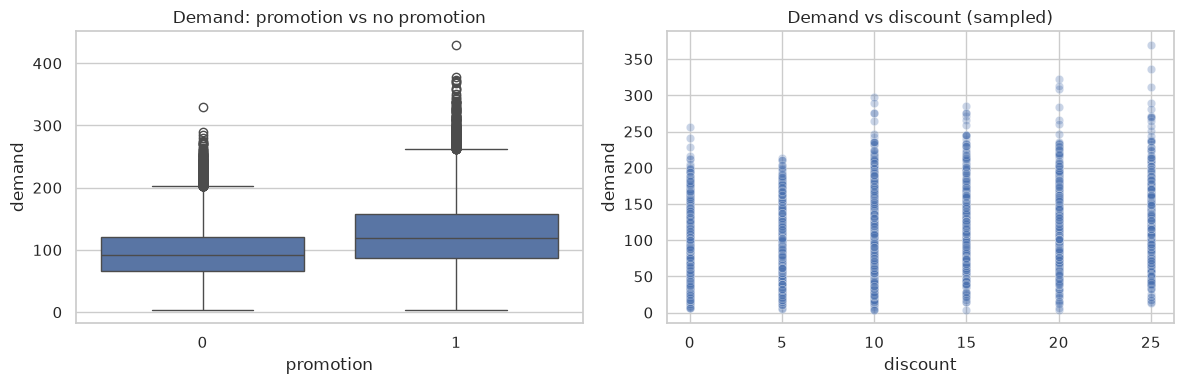

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x="promotion", y="demand", ax=axes[0])
axes[0].set_title("Demand: promotion vs no promotion")

sns.scatterplot(data=df.sample(5000, random_state=42), x="discount", y="demand", alpha=0.3, ax=axes[1])
axes[1].set_title("Demand vs discount (sampled)")
plt.tight_layout()

print(df.groupby("promotion")["demand"].mean())
print(df[["discount", "demand"]].corr())

## Correlation of numeric features with demand

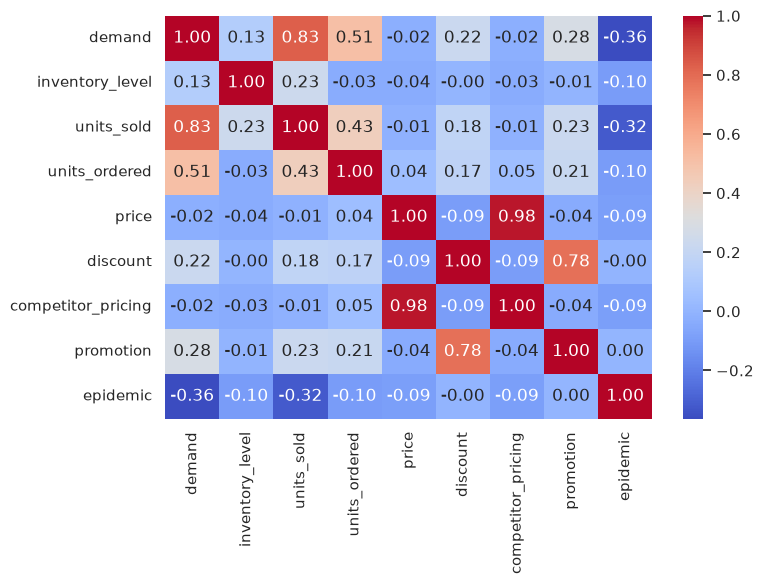

In [8]:
numeric_cols = [
    "demand",
    "inventory_level",
    "units_sold",
    "units_ordered",
    "price",
    "discount",
    "competitor_pricing",
    "promotion",
    "epidemic",
]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
plt.tight_layout()